# DANL Analysis by ANE Sensor

This notebook implements a DANL analysis based on `plot_danel.py`.
It loads per-sensor DANL vectors from CSV, validates them, builds a long-format table,
and reproduces the per-sensor DANL plot with additional summary metrics.


In [1]:
from __future__ import annotations

import json
from pathlib import Path
from typing import Dict, List, Tuple

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


# -----------------------
# Configuration
# -----------------------
DANL_CSV_CANDIDATES = [
    Path("data/danl_resume_vectors.csv"),
    Path("danl_resume_vectors.csv"),
]
OUTPUT_DIR = Path("data/plots_danl")
PLOT_FILENAME = "danl_by_ane_sensor.png"


In [2]:
def resolve_danl_csv_path(
    candidates: List[Path],  # Candidate CSV paths to probe in order
) -> Path:                  # First existing CSV path
    '''Resolve the DANL CSV path from a prioritized candidate list.

    Purpose:
    Keep the notebook robust to either repository layout used by scripts:
    CSV in `data/` or CSV at repository root.

    Parameters:
    candidates: Ordered list of candidate filesystem paths.

    Returns:
    Existing `Path` pointing to the DANL input CSV.

    Side effects:
    None.
    '''
    for csv_path in candidates:
        if csv_path.exists():
            return csv_path
    tested = ", ".join(str(path) for path in candidates)
    raise FileNotFoundError(f"Could not find DANL CSV. Tested: {tested}")


def parse_json_vector(
    text: object,  # JSON-encoded list from CSV cell
) -> np.ndarray:   # Parsed numeric vector
    '''Parse one JSON-encoded vector cell into a 1D float array.

    Purpose:
    Convert serialized frequency/DANL vectors from the CSV to numeric arrays
    that can be validated, plotted, and summarized.

    Parameters:
    text: Raw CSV cell value expected to contain a JSON list.

    Returns:
    1D numpy array of `float`.

    Side effects:
    None.
    '''
    if isinstance(text, (list, tuple, np.ndarray)):
        return np.asarray(text, dtype=float).ravel()

    parsed = json.loads(str(text))
    return np.asarray(parsed, dtype=float).ravel()


def load_danl_table(
    csv_path: Path,  # Input CSV path
) -> pd.DataFrame:  # Raw DANL dataframe
    '''Load the DANL CSV into a dataframe.

    Purpose:
    Centralize CSV reading and required-column validation before analysis.

    Parameters:
    csv_path: Location of the DANL CSV file.

    Returns:
    Raw dataframe with one row per sensor and vector columns.

    Side effects:
    Reads a CSV file from disk.
    '''
    table = pd.read_csv(csv_path)
    required_cols = {"sensor_ane", "Frequency_MHz", "Mean_DANL_dBFS"}
    missing = required_cols.difference(table.columns)
    if missing:
        missing_str = ", ".join(sorted(missing))
        raise KeyError(f"Missing required columns: {missing_str}")
    return table


def build_long_danl_table(
    raw_df: pd.DataFrame,  # Row-wise sensor vectors
) -> pd.DataFrame:          # Long-format table [sensor, freq, danl]
    '''Expand vector columns into long-format DANL samples.

    Purpose:
    Normalize row-wise vector storage into tidy samples so downstream plots
    and summary statistics can be computed consistently.

    Parameters:
    raw_df: Input dataframe with `Frequency_MHz` and `Mean_DANL_dBFS` vectors.

    Returns:
    Long-format dataframe with columns:
    `sensor_ane`, `frequency_mhz`, `mean_danl_dbfs`.

    Side effects:
    None.
    '''
    records: List[Dict[str, float | str]] = []

    # Expand each sensor row into one sample per frequency bin.
    for _, row in raw_df.iterrows():
        sensor = str(row["sensor_ane"])
        freqs_mhz = parse_json_vector(row["Frequency_MHz"])
        danl_dbfs = parse_json_vector(row["Mean_DANL_dBFS"])

        if freqs_mhz.size != danl_dbfs.size:
            raise ValueError(
                f"Length mismatch for sensor '{sensor}': "
                f"freq={freqs_mhz.size}, danl={danl_dbfs.size}"
            )

        for freq_mhz, danl_value_dbfs in zip(freqs_mhz, danl_dbfs):
            records.append(
                {
                    "sensor_ane": sensor,
                    "frequency_mhz": float(freq_mhz),
                    "mean_danl_dbfs": float(danl_value_dbfs),
                }
            )

    long_df = pd.DataFrame.from_records(records)
    if long_df.empty:
        raise ValueError("No DANL samples were parsed from the CSV")

    return long_df


def summarize_danl_by_sensor(
    long_df: pd.DataFrame,  # Long-format DANL samples
) -> pd.DataFrame:          # Summary metrics per sensor
    '''Compute per-sensor DANL summary statistics.

    Purpose:
    Provide a compact, quantitative comparison of DANL behavior across ANE
    sensors beyond visual inspection of curves.

    Parameters:
    long_df: Long-format DANL table with one row per (sensor, frequency).

    Returns:
    Summary table with count, central tendency, spread, and extrema in dBFS.

    Side effects:
    None.
    '''
    grouped = long_df.groupby("sensor_ane", sort=True)["mean_danl_dbfs"]
    summary = grouped.agg(["count", "mean", "median", "std", "min", "max"]).reset_index()
    summary = summary.rename(
        columns={
            "count": "n_points",
            "mean": "mean_dbfs",
            "median": "median_dbfs",
            "std": "std_dbfs",
            "min": "min_dbfs",
            "max": "max_dbfs",
        }
    )

    percentiles = grouped.quantile([0.10, 0.90]).unstack(level=1).reset_index()
    percentiles = percentiles.rename(columns={0.10: "p10_dbfs", 0.90: "p90_dbfs"})

    out = summary.merge(percentiles, on="sensor_ane", how="left")
    return out.sort_values(by="sensor_ane", kind="stable").reset_index(drop=True)


def plot_danl_by_sensor(
    long_df: pd.DataFrame,        # Long-format DANL samples
    output_dir: Path,             # Directory where figure is saved
    output_filename: str,         # Plot image filename
) -> Tuple[plt.Figure, plt.Axes, Path]:  # Figure, axes, saved path
    '''Plot DANL curves per ANE sensor and save the figure.

    Purpose:
    Reproduce the core plot from `plot_danel.py` in notebook form while
    keeping deterministic output storage for reports.

    Parameters:
    long_df: Long-format DANL table with one row per frequency sample.
    output_dir: Directory where the PNG file is written.
    output_filename: Name of the output PNG file.

    Returns:
    `(figure, axes, plot_path)` for optional post-processing.

    Side effects:
    Creates output directory and writes a PNG file to disk.
    '''
    fig, ax = plt.subplots(figsize=(12, 7))

    # Plot one curve per sensor with lightweight markers for sample visibility.
    for sensor_name, sensor_df in long_df.groupby("sensor_ane", sort=True):
        sensor_df = sensor_df.sort_values(by="frequency_mhz", kind="stable")
        ax.plot(
            sensor_df["frequency_mhz"].to_numpy(dtype=float),
            sensor_df["mean_danl_dbfs"].to_numpy(dtype=float),
            label=str(sensor_name),
            marker="o",
            markersize=2.5,
            linewidth=1.0,
            alpha=0.95,
        )

    ax.set_xlabel("Frequency (MHz)")
    ax.set_ylabel("Mean DANL (dBFS)")
    ax.set_title("DANL by ANE Sensor")
    ax.grid(True, alpha=0.35, linewidth=0.7)
    ax.legend(ncol=2, fontsize=8)

    output_dir.mkdir(parents=True, exist_ok=True)
    plot_path = output_dir / output_filename
    fig.tight_layout()
    fig.savefig(plot_path, dpi=150, bbox_inches="tight")

    return fig, ax, plot_path


In [3]:
danl_csv_path = resolve_danl_csv_path(DANL_CSV_CANDIDATES)
raw_danl_df = load_danl_table(danl_csv_path)
long_danl_df = build_long_danl_table(raw_danl_df)
sensor_summary_df = summarize_danl_by_sensor(long_danl_df)

print(f"Loaded DANL CSV: {danl_csv_path}")
print(f"Rows (raw sensors): {len(raw_danl_df)}")
print(f"Rows (long samples): {len(long_danl_df)}")
print(f"Sensors: {long_danl_df['sensor_ane'].nunique()}")


Loaded DANL CSV: data/danl_resume_vectors.csv
Rows (raw sensors): 10
Rows (long samples): 1191
Sensors: 10


In [4]:
sensor_summary_df


,sensor_ane,n_points,mean_dbfs,median_dbfs,std_dbfs,min_dbfs,max_dbfs,p10_dbfs,p90_dbfs
0,ANE1,120,-80.509667,-79.045,2.797887,-84.13,-62.80,-83.760,-78.779
1,ANE10,119,-87.033193,-86.780,1.790028,-94.62,-85.05,-87.624,-85.688
2,ANE2,119,-90.197731,-90.290,0.396569,-90.98,-89.31,-90.642,-89.616
3,ANE3,119,-87.016807,-85.860,2.224806,-92.14,-84.12,-90.422,-84.964
4,ANE4,119,-81.810504,-81.400,1.550635,-92.35,-80.51,-82.796,-80.900
5,ANE5,119,-98.028319,-97.980,0.568659,-99.90,-96.96,-98.688,-97.424
6,ANE6,119,-107.237311,-108.100,1.598712,-109.15,-103.93,-108.722,-104.824
7,ANE7,119,-88.186387,-87.870,2.046531,-96.35,-84.62,-90.134,-86.356
8,ANE8,119,-88.374034,-87.790,4.349133,-108.36,-84.38,-91.312,-84.720
9,ANE9,119,-97.627563,-97.490,1.114305,-102.50,-95.20,-98.002,-96.852


Saved DANL plot to: data/plots_danl/danl_by_ane_sensor.png


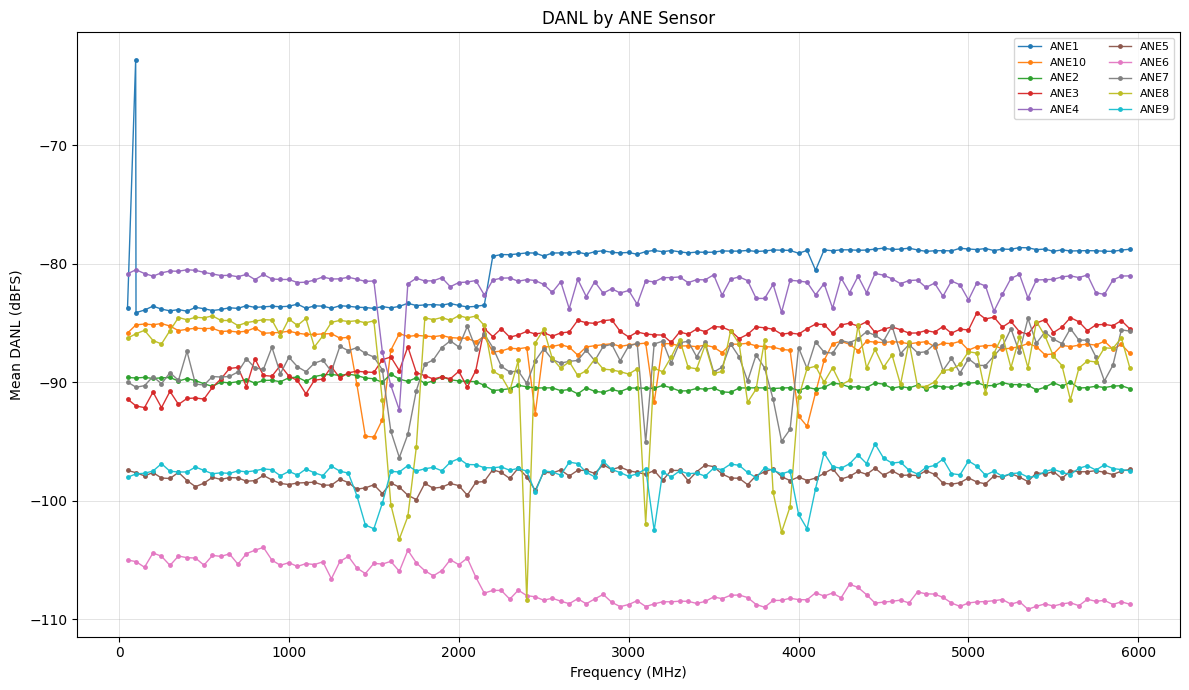

In [5]:
fig, ax, danl_plot_path = plot_danl_by_sensor(
    long_df=long_danl_df,
    output_dir=OUTPUT_DIR,
    output_filename=PLOT_FILENAME,
)
print(f"Saved DANL plot to: {danl_plot_path}")
plt.show()


In [6]:
# Optional export for downstream reporting.
summary_csv_path = Path("data/danl_sensor_summary.csv")
summary_csv_path.parent.mkdir(parents=True, exist_ok=True)
sensor_summary_df.to_csv(summary_csv_path, index=False)
print(f"Saved summary table to: {summary_csv_path}")


Saved summary table to: data/danl_sensor_summary.csv
